Siamo molto bravi a programmare


In [ ]:
import math
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

from collections import defaultdict
from scipy.stats import pearsonr

DATASET_FOLDER = "dataset/"

Poi abbiamo importato

In [ ]:
artists = pd.read_csv(DATASET_FOLDER + 'artists.csv', sep=';')
tracks = pd.read_csv(DATASET_FOLDER + 'tracks.csv', sep=',')

print(artists.head())


In [ ]:
print(tracks.head())

In [ ]:
artists_p = artists.add_prefix("artist_")
tracks_p = tracks.add_prefix("track_")

merged = tracks_p.merge(
    artists_p,
    how="left",
    left_on="track_id_artist",
    right_on="artist_id_author"
)

track_cols = [c for c in merged.columns if c.startswith("track_")]
artist_cols = [c for c in merged.columns if c.startswith("artist_")]

merged.drop(columns=["artist_active_end"], inplace=True)

print(merged.head())

#print(merged["artist_active_end"].unique())

In [ ]:
print('Numero canzoni:', len(merged))
print('Numero canzoni unique:', len(merged.track_id.unique()))

# Drop duplicate track_ids, keeping the first occurrence
merged = merged.drop_duplicates(subset=['track_id'], keep='first')

print('Numero canzoni unique (trimmed):', len(merged.track_id.unique()))
print('Numero artisti:', len(merged.artist_id_author.unique()))

In [ ]:
print(merged.info())

In [ ]:
for i in merged.columns:
    n= merged[i].isnull().sum()
    print(f"{i}: {n} null")


In [ ]:
duplicated_tracks= len(merged) - len(merged.track_id.unique())
print('Numero canzoni duplicate:', duplicated_tracks)

In [ ]:
unique= []
for _, row in merged.iterrows():
    name_artist = str(row["track_name_artist"]).lower()
    artist_name = str(row["artist_name"]).lower()
    primary_artist = str(row["track_primary_artist"]).lower()
    triple = (name_artist, artist_name, primary_artist)

    if name_artist != artist_name or name_artist != primary_artist or artist_name != primary_artist:
        if triple not in unique:
            unique.append(triple)
print(unique)

In [ ]:
merged['track_album_release_date'].head(30)


In [ ]:
float_cols = merged.select_dtypes(include=['float64']).columns
for col in float_cols:
    series = pd.to_numeric(merged[col], errors="coerce")
    mean = series.mean()
    std_dev = series.std()
    outliers = series[series.sub(mean).abs() > 5 * std_dev]
    count= len(outliers)
    print(f"{col}: {count} outliers " )

In [ ]:
merged['track_year'].unique()

In [ ]:
merged["artist_active_start_year"] = (
    pd.to_numeric(merged["artist_active_start"].astype(str).str.slice(0, 4), errors="coerce")
    .astype("Int64")
)

In [ ]:
# condizione da eliminare: col_a > 10 e col_b == "X"
track_year_num = pd.to_numeric(merged["track_year"], errors="coerce")
active_start_year_num = pd.to_numeric(merged["artist_active_start_year"], errors="coerce")
mask = (track_year_num > active_start_year_num) & (track_year_num < 2027)
merged["track_year"] = track_year_num.where(mask, pd.NA)

In [ ]:
merged['track_year'].unique()

In [ ]:
merged["track_tot_swear_words"] = merged["track_swear_IT"] + merged["track_swear_EN"]
for col_name in ["track_popularity", "track_stats_pageviews", "track_bpm", "track_duration_ms", 
                 "track_lexical_density", "track_year", "track_loudness", "track_tot_swear_words",
                 "track_centroid"]:
    print(merged[col_name].dtype)
    merged[col_name] = pd.to_numeric(merged[col_name], errors="coerce")
    plt.figure()
    merged[col_name].hist()
    plt.title(col_name)
    plt.xlabel(col_name)
    plt.yscale('log')
    plt.show()

# Istogramma cumulativo con IT/EN separati (colori diversi)
swear_it = pd.to_numeric(merged["track_swear_IT"], errors="coerce")
swear_en = pd.to_numeric(merged["track_swear_EN"], errors="coerce")
plt.figure()
plt.hist([swear_it, swear_en], bins=30, stacked=True, label=["IT", "EN"], alpha=0.8)
plt.title("Swear words (IT vs EN)")
plt.xlabel("Swear words")
plt.ylabel("Count")
plt.legend()
plt.show()

In [ ]:
merged["track_presumed_flatness"] = pd.to_numeric(merged["track_spectral_complexity"], errors="coerce") / (
    pd.to_numeric(merged["track_rolloff"], errors="coerce") - pd.to_numeric(merged["track_centroid"], errors="coerce")
)

merged["track_avg_swear_words"] = merged["track_tot_swear_words"] / merged["track_n_tokens"]


merged["artist_birth_year"] = (
    pd.to_numeric(merged["artist_birth_date"].astype(str).str.slice(0, 4), errors="coerce")
    .astype("Int64")
)

merged["track_artist_age"]= merged["track_year"] - merged["artist_birth_year"]

merged["track_tokens_per_sec"] = merged["track_n_tokens"] / (merged["track_duration_ms"] / 1000)


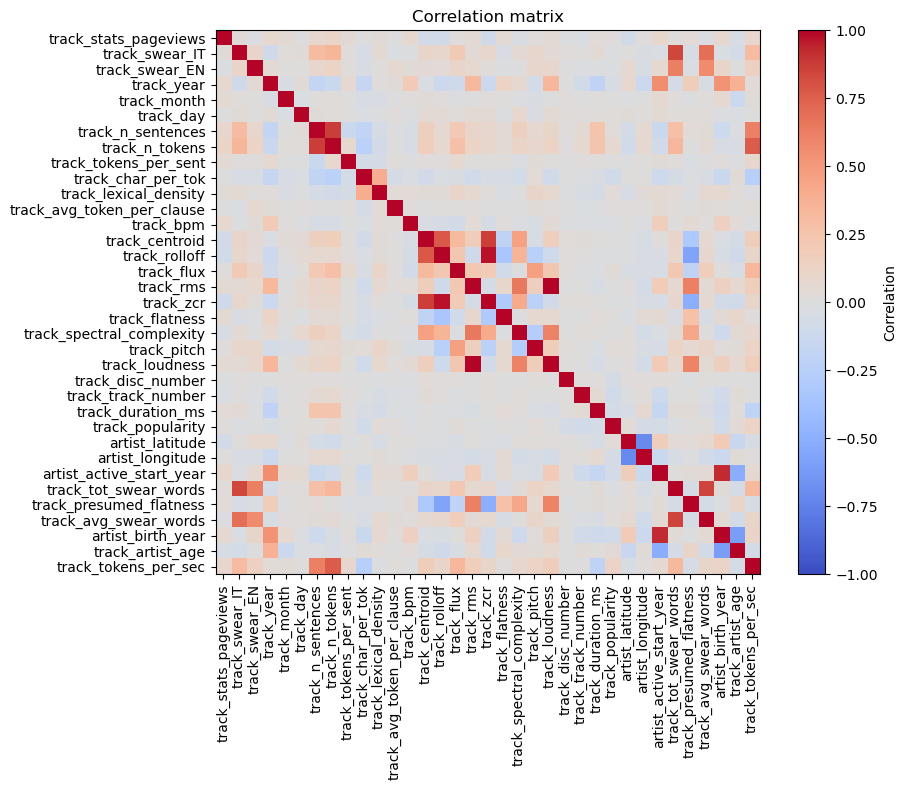

Strongly correlated pairs:
track_rms                  track_loudness               0.995550
track_rolloff              track_zcr                    0.969144
artist_active_start_year   artist_birth_year            0.927034
track_n_sentences          track_n_tokens               0.867862
track_centroid             track_zcr                    0.864460
track_tot_swear_words      track_avg_swear_words        0.850638
track_swear_IT             track_tot_swear_words        0.841941
track_centroid             track_rolloff                0.775799
track_n_tokens             track_tokens_per_sec         0.760865
track_swear_IT             track_avg_swear_words        0.692821
track_rms                  track_spectral_complexity    0.643962
track_swear_EN             track_tot_swear_words        0.624154
track_rms                  track_presumed_flatness      0.616247
track_n_sentences          track_tokens_per_sec         0.610060
track_spectral_complexity  track_loudness               0.60852

In [435]:
# Correlation heatmap for numeric columns
corr = merged.select_dtypes(include="number").corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
strong_pairs = corr_pairs.stack().sort_values(ascending=False)
print("Strongly correlated pairs:")
print(strong_pairs[strong_pairs.abs() > 0.5])

Tra rms e loudness teniamo loudness 
tra rolloff, zcr, e centroid teniamo centroid
tra n_sentences e n_token teniamo n_tokens
tra latitude e longitude teniamo latitude
tra swear words IT ed ENG teniamo IT

(1, 1000000.0)

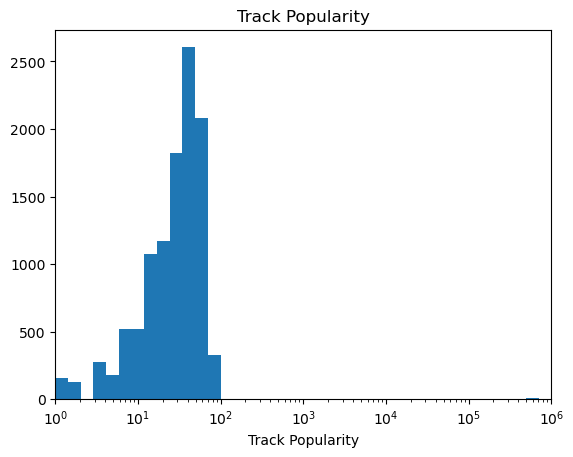

In [436]:
merged['track_popularity'] = pd.to_numeric(merged['track_popularity'], errors="coerce")
pop = merged['track_popularity'].dropna()
pop = pop[pop > 0]  # log bins need positive values

bins = np.logspace(np.log10(1), np.log10(1e6), 40)  # 40 log-width bins

plt.figure('1')
plt.hist(pop, bins=bins)
plt.xscale('log')
plt.title('Track Popularity')
plt.xlabel('Track Popularity')
plt.xlim(1, 1e6)


**Discretization strategy (justification)**
- BPM: cut at 90 and 120 BPM, common musicology thresholds for slow/medium/fast tempos.
- Popularity: use 0–30–70–100 to map to low/medium/high on a 0–100 scale.
- Duration: short < 3 min, medium 3–5 min, long > 5 min (typical radio lengths).
- Swear density: compute swear words per minute; split low/high by median to avoid skew from heavy tails.

In [437]:
# Discretize numeric variables into categorical bins
bpm = pd.to_numeric(merged["track_bpm"], errors="coerce")
pop = pd.to_numeric(merged["track_popularity"], errors="coerce")
dur = pd.to_numeric(merged["track_duration_ms"], errors="coerce")
swear_it = pd.to_numeric(merged["track_swear_IT"], errors="coerce")
swear_en = pd.to_numeric(merged["track_swear_EN"], errors="coerce")
swear_total = swear_it.add(swear_en, fill_value=0)

# Swear density = swear words per minute
duration_min = dur / 60000
swear_density = swear_total / duration_min
swear_density = swear_density.replace([np.inf, -np.inf], np.nan)

encoded = pd.get_dummies([])

encoded["bpm"] = pd.cut(
    bpm,
    bins=[-np.inf, 90, 120, np.inf],
    labels=["Slow", "Medium", "Fast"]
 )

encoded["popularity"] = pd.cut(
    pop,
    bins=[-np.inf, 1e1, 1e2, np.inf],
    labels=["Low", "Medium", "High"]
 )

encoded["duration"] = pd.cut(
    dur,
    bins=[-np.inf, 180000, 300000, np.inf],
    labels=["Short", "Medium", "Long"]
 )

median_swear_density = swear_density.median(skipna=True)
encoded["swear_density"] = pd.cut(
    swear_density,
    bins=[-np.inf, median_swear_density, np.inf],
    labels=["Low", "High"]
 )

encoded["lexical_density"] = pd.cut(
    pd.to_numeric(merged["track_lexical_density"], errors="coerce"),
    bins=[-np.inf, 0.5, np.inf],
    labels=["Low", "High"]
 )

 
encoded["loudness"] = pd.cut(
    pd.to_numeric(merged["track_loudness"], errors="coerce"),
    bins=[-np.inf, 27, 54, np.inf],
    labels=["Soft", "Medium", "Loud"]
 )

encoded["acuteness"] = pd.cut(
    pd.to_numeric(merged["track_centroid"], errors="coerce"),
    bins=[-np.inf, 0.15, np.inf],
    labels=["Low", "High"]
 )

encoded.head()

,bpm,popularity,duration,swear_density,lexical_density,loudness,acuteness
0,Fast,Medium,Medium,High,High,Soft,High
1,Fast,Medium,Medium,High,High,Soft,High
2,Fast,Medium,Medium,High,High,Medium,High
3,Fast,Medium,Short,High,High,Soft,Low
4,Medium,Medium,Medium,Low,Low,Soft,Low


In [438]:
print(encoded['swear_density'].value_counts())


swear_density
Low     5508
High    5507
Name: count, dtype: int64


In [439]:
import sys

from mlxtend import __version__ as mlxtend_version
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

In [440]:
# Build transactions with explicit col_name_value labels
transactions = encoded.apply(lambda row: [f"{col}_{row[col]}" for col in encoded.columns], axis=1).tolist()
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_array, columns=te.columns_)
df.head()

,acuteness_High,acuteness_Low,acuteness_nan,bpm_Fast,bpm_Medium,bpm_Slow,bpm_nan,duration_Long,duration_Medium,duration_Short,...,loudness_Medium,loudness_Soft,loudness_nan,popularity_High,popularity_Low,popularity_Medium,popularity_nan,swear_density_High,swear_density_Low,swear_density_nan
0,True,False,False,True,False,False,False,False,True,False,...,False,True,False,False,False,True,False,True,False,False
1,True,False,False,True,False,False,False,False,True,False,...,False,True,False,False,False,True,False,True,False,False
2,True,False,False,True,False,False,False,False,True,False,...,True,False,False,False,False,True,False,True,False,False
3,False,True,False,True,False,False,False,False,False,True,...,False,True,False,False,False,True,False,True,False,False
4,False,True,False,False,True,False,False,False,True,False,...,False,True,False,False,False,True,False,False,True,False


In [441]:
frequent_itemsets = apriori(df, min_support=2e-2, use_colnames=True)
frequent_itemsets.sort_values("support", ascending=False)

,support,itemsets
13,0.834580,(popularity_Medium)
1,0.683314,(acuteness_Low)
6,0.620481,(duration_Medium)
11,0.610295,(loudness_Soft)
8,0.598936,(lexical_density_High)
...,...,...
1003,0.020103,"(swear_density_High, acuteness_High, popularit..."
532,0.020103,"(duration_Medium, swear_density_Low, acuteness..."
1392,0.020103,"(loudness_Soft, swear_density_High, popularity..."
464,0.020013,"(swear_density_High, bpm_Fast, lexical_density..."


In [442]:
rules_conf = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.6,
    num_itemsets=len(df.index),
)

columns_to_show = [
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift",
    "leverage",
    "conviction",
]

rules_conf[columns_to_show].sort_values(["leverage", "lift"], ascending=False).head(20)

,antecedents,consequents,support,confidence,lift,leverage,conviction
46,(swear_density_High),(lexical_density_High),0.331470,0.667696,1.114803,0.034135,1.206917
329,"(swear_density_High, popularity_Medium)",(lexical_density_High),0.287208,0.674286,1.125805,0.032095,1.231336
323,"(loudness_Medium, lexical_density_High)",(swear_density_High),0.151717,0.618978,1.246835,0.030035,1.321604
177,"(acuteness_Low, lexical_density_Low)",(swear_density_Low),0.166682,0.604051,1.216546,0.029669,1.271554
1065,"(swear_density_High, loudness_Medium)","(popularity_Medium, lexical_density_High)",0.137204,0.644369,1.270979,0.029253,1.386307
1064,"(popularity_Medium, loudness_Medium, lexical_d...",(swear_density_High),0.137204,0.630489,1.270022,0.029171,1.362776
847,"(bpm_Fast, swear_density_High)","(popularity_Medium, lexical_density_High)",0.128279,0.635552,1.253587,0.025949,1.352767
81,"(acuteness_High, lexical_density_High)",(swear_density_High),0.121608,0.625116,1.259199,0.025032,1.343244
322,"(swear_density_High, loudness_Medium)",(lexical_density_High),0.151717,0.712532,1.189662,0.024188,1.395158
461,"(popularity_Medium, acuteness_High, lexical_de...",(swear_density_High),0.103128,0.644144,1.297529,0.023648,1.415070
